In [1]:
import io
from datetime import datetime
import torch
import numpy as np
from model import *
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


In [2]:
device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "xpu"
        if torch.xpu.is_available()
        else "cpu"
    )
print(f"Using {device} device")

Using cpu device


In [3]:
from YOLO_loader import get_classes

DIRECTORY = "face_dataset"

N_CELL = 52
IMG_SIZE = 416
N_ANCHORS = 3
TARGET_SIZE= (IMG_SIZE,IMG_SIZE)
BATCH_SIZE = 4
N_CLASS = len(get_classes(DIRECTORY))
λ_coord = 5.0
λ_noobj = 0.5
λ_obj   = 1.0
λ_class = 1.0

answer = input("Do you want to load a model?(Yes/No)\n")
model = LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=3,base_kernel_num=16,divider =1)
print(model)
model = model.to(device) 
if answer == "Yes":
  nom = input("name of the file\n")
  model.load_state_dict(torch.load("model/"+nom))

loss_fn = YoloLoss(lambda_coord=5.0, lambda_noobj=0.5, lambda_obj=1.0)
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

test_loss =0.0
val_loss = 0.0

LightweightYOLO(
  (backbone): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilati

### Récupération des 3 ratios les plus probables ###

Traitement des labels:   0%|          | 0/12880 [00:00<?, ?it/s]

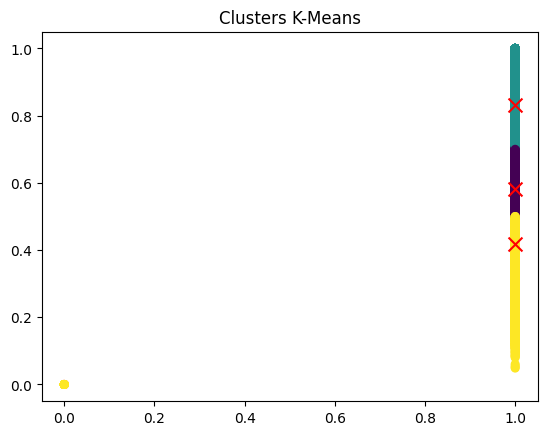

In [4]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from YOLO_loader import get_labels
import time


labels = get_labels(DIRECTORY)
ratios = []
for label in tqdm(labels, desc="Traitement des labels", leave=True):
    boxes = label.get_bounding_boxes()
    for box in boxes :
        box_ratios = box.get_ratio()
        ratios.append(box_ratios)  
    time.sleep(0)
    
ratios = np.array(ratios)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(ratios)  

labels = kmeans.labels_
centers = kmeans.cluster_centers_


plt.scatter(ratios[:, 0], ratios[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100)
plt.title("Clusters K-Means")
plt.show()

### CREATE DATASET ###


In [5]:
from dataset import CardRecognitionDataset

reduction_factor = model.get_reduction_factor()

dataset = CardRecognitionDataset(directory= DIRECTORY,is_dark_and_white=False,reduction_factor=reduction_factor,bounding_boxes_ratio=centers)
STD = dataset.get_std()
MEAN = dataset.get_mean()

c:\Programmation\object_recognition_tipe\.venv\Lib\site-packages\albumentations\core\validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Programmation\object_recognition_tipe\dataset.py:31: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  Albu.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1),
c:\Programmation\object_recognition_tipe\dataset.py:33: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  Albu.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1),
c:\Programmation\object_recognition_tipe\dataset.py:37: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  Albu.CoarseDropout(
c:\Programmation\object_recognition_tipe\dataset.py:50: UserWarning: Argument(s) 'quality_lower, quality_

Traitement des labels:   0%|          | 0/3832 [00:00<?, ?it/s]

Mean: [0.485, 0.456, 0.406]
Std:  [0.229, 0.224, 0.225]


### CREATE DATA LOADER ###

In [6]:
from dataset import custom_collate_fn, CustomBatchSampler
from torch.utils.data import Subset,DataLoader
import random

N = dataset.__len__()
train_size = int(0.7 * N)
val_size   = int(0.2 * N)   
indices = torch.randperm(N)
test_size  = N - train_size - val_size

full_groups = dataset.get_image_size_groups()

train_groups = {}
val_groups = {}
test_groups = {}

# 2. Diviser CHAQUE groupe en Train/Val/Test pour préserver l'équilibre des tailles
for size, indices in full_groups.items():
    # Mélanger les indices de ce groupe spécifique
    random.shuffle(indices)
    
    n_total = len(indices)
    n_train = int(0.7 * n_total)
    n_val   = int(0.2 * n_total)
    
    train_groups[size] = indices[:n_train]
    val_groups[size]   = indices[n_train:n_train+n_val]
    test_groups[size]  = indices[n_train+n_val:]

# 3. Créer les Samplers avec ces groupes filtrés
train_sampler = CustomBatchSampler(dataset, BATCH_SIZE, groups=train_groups)
val_sampler   = CustomBatchSampler(dataset, BATCH_SIZE, groups=val_groups)
test_sampler  = CustomBatchSampler(dataset, BATCH_SIZE, groups=test_groups)

# 4. Créer les DataLoaders
train_loader = DataLoader(dataset, batch_sampler=train_sampler, collate_fn=custom_collate_fn, num_workers=0)
val_loader   = DataLoader(dataset, batch_sampler=val_sampler,   collate_fn=custom_collate_fn, num_workers=0)
test_loader  = DataLoader(dataset, batch_sampler=test_sampler,  collate_fn=custom_collate_fn, num_workers=0)

print(len(dataset))
print(len(train_loader))

3832
717


In [ ]:
from YOLO_loader import BoundingBox, CustomImage
from utils import find_objects
import math


torch.set_printoptions(threshold=2000)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

def run_one_epoch(loader:DataLoader, train=True):
    model.train(train)
    running_loss = 0.0
    preds, targets = [], []

    for images, labels in tqdm(loader,desc="batch : ",leave=True):
        inputs = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.float32)


        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)


            if train:
                loss.backward()
                optimizer.step()
                if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
                    scheduler.step()

            else :
                copied_labels = torch.clone(labels).detach().cpu()
                copied_outputs = torch.clone(outputs).detach().cpu()
                copied_inputs = torch.clone(inputs).detach().cpu()
                B,grid_division_y,grid_division_x,A,S = copied_outputs.shape
                H, W = copied_inputs.shape[2], copied_inputs.shape[3]
                images = []
                for i in range(B):

                    input_boxes = []
                    indices = find_objects(copied_labels[i])
                    for indice in indices:
                        input_boxes.append(BoundingBox.from_tensor(copied_labels[i,indice[0],indice[1],indice[2],:],N_CLASS,grid_division_x,grid_division_y))

                    custom_img= CustomImage.from_tensor(image_tensor=inputs[i],bounding_boxes=input_boxes,
                                       target_size=(W,H),reduction_factor=reduction_factor)
                    B,grid_division_y, grid_division_x, A, S = copied_outputs.shape
                    W, H = custom_img.target_size
                    output_bb_boxes = []
                    for bb_box in custom_img.get_bounding_boxes():
                        position = bb_box.get_cell_position(grid_division_x,grid_division_y)

                        anchor_index = bb_box.get_bounding_box_index(centers)
                        x,y = position
                        output_bb_boxes.append([BoundingBox.from_tensor(copied_outputs[i,int(x),int(y),a,:],N_CLASS,int(x),int(y),grid_division_x,grid_division_y) for a in range(3)])
                    output_bb_boxes = np.array(output_bb_boxes, dtype=torch.float32).flatten()
                    images.append(custom_img.get_image(output_bb_boxes))

                images_np = np.array(images)  # (B,H,W,C)
                batch_size = images_np.shape[0]
                grid_size = math.ceil(math.sqrt(batch_size))  # Taille de la grille

                fig, axes = plt.subplots(grid_size, grid_size, figsize=(4*grid_size, 4*grid_size))
                axes = axes.flatten()  # Pour itérer facilement même si c'est 2D

                for i in range(batch_size):
                    axes[i].imshow(images_np[i])
                    axes[i].axis('off')

                # Masquer les axes vides si batch_size < grid_size**2
                for i in range(batch_size, grid_size**2):
                    axes[i].axis('off')

                plt.tight_layout()
                plt.show()
        running_loss += loss.item()

        if not train:
            preds.append(outputs.detach().cpu())
            targets.append(labels.detach().cpu())

    epoch_loss = running_loss / len(loader)

    if train and scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
        scheduler.step(epoch_loss)

    if train:
        return epoch_loss
    else:
        return torch.cat(preds), torch.cat(targets), epoch_loss


In [12]:
num_epochs = 50
model.train(True)
for epoch in range(num_epochs):
    loss = run_one_epoch(train_loader, True)
    #preds, targets, val_loss = run_one_epoch(val_loader, train=False)
    print(f"Epoch {epoch} loss: {loss} (type: {type(loss)})")

batch :   0%|          | 0/717 [00:01<?, ?it/s]


AttributeError: 'NoneType' object has no attribute 'scale'

In [ ]:

preds, targets, val_loss = run_one_epoch(val_loader, train=False)
print(f"Epoch {epoch} loss: {loss} (type: {type(loss)})")

In [ ]:
torch.save(model.state_dict(), 'model/version6.pth')